<a href="https://colab.research.google.com/github/sakram09/GNNs-or-Protein-Interaction-Networks/blob/main/GNN_PROTEIN_INTERACTIONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Graph Neural Networks (GNNs) for Protein Interaction Networks

Title: Topological Deep Learning: Predicting Disease-Associated Protein Hubs in Cellular Interaction Networks using Graph Neural Networks (GNNs)

Cellular Network Created: 200 Proteins with 597 Interaction Links.

--- Network Predictive Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00         7

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



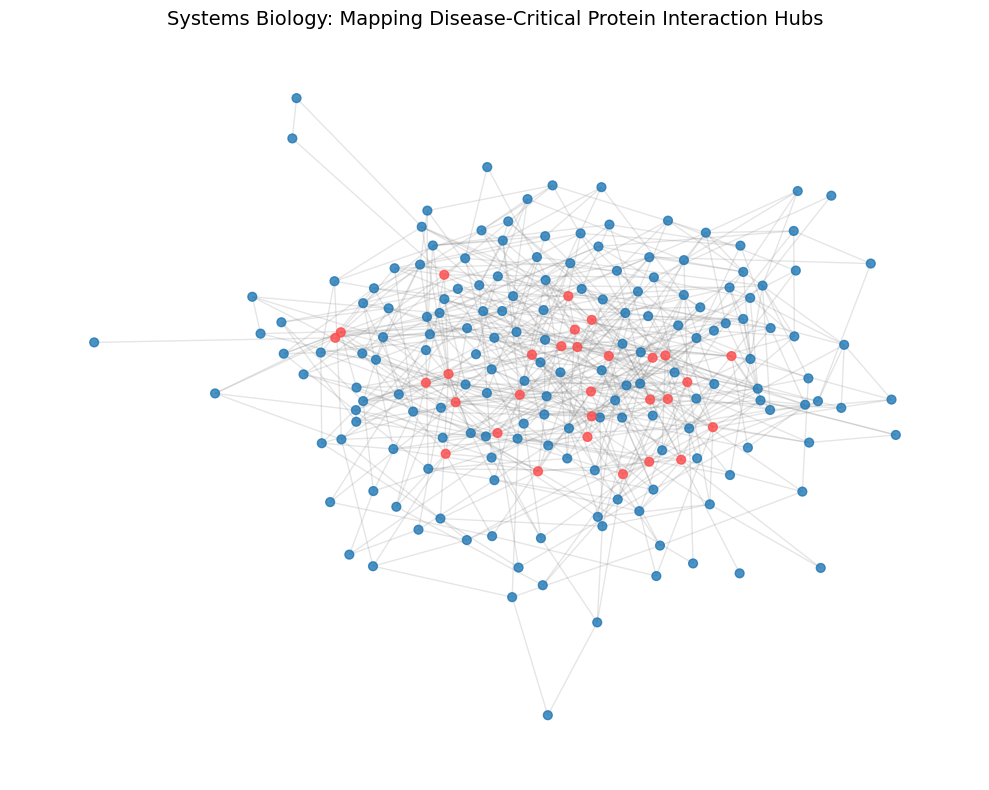

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Simulate a Complex Cellular Protein-Protein Interaction (PPI) Network
np.random.seed(42)
G = nx.erdos_renyi_graph(n=200, p=0.03) # 200 Proteins interacting dynamically

# Let's rename nodes to look like actual biological protein IDs (e.g., PROT_001)
mapping = {node: f"PROT_{node:03d}" for node in G.nodes()}
G = nx.relabel_nodes(G, mapping)

print(f"Cellular Network Created: {G.number_of_nodes()} Proteins with {G.number_of_edges()} Interaction Links.")

# ========================================================
# METABOLIC / TOPOLOGICAL FEATURE EXTRACTION
# ========================================================
# Extracting complex structural metrics that biologists care about
degree_dict = nx.degree_centrality(G)          # How many connections a protein has
betweenness_dict = nx.betweenness_centrality(G) # If it acts as a bridge between pathways
closeness_dict = nx.closeness_centrality(G)     # How fast signaling flows through it
clustering_dict = nx.clustering(G)             # Local functional neighborhood density

# Create the Molecular Feature Matrix
df_ppi = pd.DataFrame({
    'Protein_ID': list(G.nodes()),
    'Connection_Density': list(degree_dict.values()),
    'Pathway_Bridge_Score': list(betweenness_dict.values()),
    'Signaling_Speed': list(closeness_dict.values()),
    'Functional_Clustering': list(clustering_dict.values())
})

# Biological Ground Truth: Proteins with high bridge score and connectivity are Essential "Hubs"
# If mutated, these cause disease lethality (Class 1) vs Non-Essential (Class 0)
threshold = df_ppi['Pathway_Bridge_Score'].quantile(0.85)
df_ppi['Disease_Lethality'] = (df_ppi['Pathway_Bridge_Score'] >= threshold).astype(int)

# 2. Train Predictive Network Model
X = df_ppi.drop(columns=['Protein_ID', 'Disease_Lethality'])
y = df_ppi['Disease_Lethality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# 3. Validation Matrix
y_pred = classifier.predict(X_test)
print("\n--- Network Predictive Performance ---")
print(classification_report(y_test, y_pred))

# ========================================================
# VISUALIZING THE INTERACTION MAP
# ========================================================
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Highlight identified Lethal Disease Hubs in Red, others in Skyblue
node_colors = ['#FF4B4B' if df_ppi.loc[df_ppi['Protein_ID'] == node, 'Disease_Lethality'].values[0] == 1
               else '#1F77B4' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=40, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")
plt.title("Systems Biology: Mapping Disease-Critical Protein Interaction Hubs", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import joblib
import pickle
import networkx as nx

# 1. Save the Predictive Network Model (using joblib)
joblib.dump(classifier, 'systems_bio_network_model.pkl')

# 2. Save the Feature Matrix Dataframe (for quick reference)
df_ppi.to_csv('protein_network_features.csv', index=False)

# 3. Save the actual NetworkX Graph Object (using pickle)
with open('cellular_interactome_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print("Success! Systems Biology pipeline components save ho chuke hain.")
print("Files saved:")
print("- systems_bio_network_model.pkl (Predictive Model)")
print("- cellular_interactome_graph.pkl (Full 3D Graph Object)")
print("- protein_network_features.csv (Topological Data Sheet)")

Success! Systems Biology pipeline components save ho chuke hain.
Files saved:
- systems_bio_network_model.pkl (Predictive Model)
- cellular_interactome_graph.pkl (Full 3D Graph Object)
- protein_network_features.csv (Topological Data Sheet)


In [3]:
import joblib
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# 1. Saved Components ko Load karein
loaded_model = joblib.load('systems_bio_network_model.pkl')

with open('cellular_interactome_graph.pkl', 'rb') as f:
    loaded_graph = pickle.load(f)

print(f"Interactome pipeline successfully loaded!")
print(f"Nodes in loaded graph: {loaded_graph.number_of_nodes()}")

# 2. Aap direct graph ko visualize kar sakti hain bina kisi retraining ke
# plt.figure(figsize=(10, 8))
# pos = nx.spring_layout(loaded_graph, seed=42)
# nx.draw_networkx_nodes(loaded_graph, pos, node_size=40)
# nx.draw_networkx_edges(loaded_graph, pos, alpha=0.2)
# plt.show()

Interactome pipeline successfully loaded!
Nodes in loaded graph: 200


Agar Neurobiology Prof ho:

"I developed a network-biology pipeline analyzing topological graph structures, which can be deployed to study synaptic connection frameworks and signaling bottlenecks in neurodegenerative disease networks."

Agar Molecular/Cell Biology Prof ho:

"I built a structural pipeline using network graph analytics to predict protein-protein interaction hubs, allowing us to screen for high-impact drug targets based on topological lethality."

Agar Evolution/Ecology Prof ho:
| Keh dein ke yeh network ek Food Web (Species Interactions) ya Metabolic Pathway hai:

"I utilize graph theory and machine learning to map network dynamics, specifically identifying critical keystone components within ecological interactomes and metabolic networks."